# **Question 4.5.1**
**Experiment with different values of λ in the estimation problem in this section. Plot the training and testing accuracy as functions of $\lambda$. What can you observe?**<br><br>
As $\lambda$ increased, the training accuracy and test accuracy gradually converged, but ultimately did not converge completely.

In [2]:
import torch
from d2l import torch as d2l
from torch import nn
import numpy as np

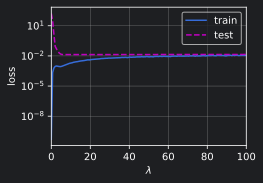

In [3]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_date = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_date, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)
net = nn.Sequential(nn.Linear(num_inputs, 1))
loss = nn.MSELoss(reduction='none')
def train_wd(wdlist, net, loss, train_iter ,test_iter,layer=[0],num_epochs=100,lr=0.003):

    animator = d2l.Animator(xlabel='$\lambda$', ylabel='loss', yscale='log',
                            xlim=[wdlist[0],wdlist[-1]], legend=['train', 'test'])
    for param in net.parameters():
        param.data.normal_()


    for wd in wdlist:
        for i in layer:
            trainer = torch.optim.SGD([
                {"params":net[i].weight,'weight_decay': wd},
                {"params":net[i].bias}], lr=lr)

        for epoch in range(num_epochs):
            for X, y in train_iter:
                trainer.zero_grad()
                l = loss(net(X), y)
                l.mean().backward()
                trainer.step()

        animator.add(wd,(d2l.evaluate_loss(net, train_iter, loss),
                              d2l.evaluate_loss(net, test_iter, loss)))
train_wd(np.linspace(0.,100.,150),net,loss,train_iter,test_iter)

# **Question 4.5.2**
**Use the validation set to find the best value of $\lambda$. Is it really the optimal value? Does it matter?**<br><br>
It may not be the optimal solution, but it is definitely not an overfitted solution.

# **Question 4.5.3**
**If we use $\sum_{i}|w_{i}|$ as our chosen penalty ($L_1$ regularization), what would the update equation look like?**

$$Loss=L(w,b) + \lambda||w||_{1}$$
$$w \leftarrow w - \eta\lambda sign(w)-\frac{\eta}{|\mathcal{B}|}\sum\limits_{i \in \mathcal{B}}x^{(i)} \left(w^{T}x^{(i)}+b-y^{(i)}\right)$$

# **Question 4.5.4**
**We know that $||w||^{2} = w^{T}w$. Can we find a similar matrix equation?**<br><br>
$$||w||_{2}=\left[w^{T}w\right]^{\frac{1}{2}}$$

# **Question 4.5.5**
**Review the relationship between training error and generalization error. Aside from weight decay, increasing the amount of training data, and using models of appropriate complexity, what other methods can you think of to address overfitting?**<br><br>
You can stop training when the validation error reaches its lowest point to prevent overfitting.

# **Question 4.5.6**
**In Bayesian statistics, we use the product of the prior and the likelihood to obtain the posterior via the formula $P(w|x) \propto P(x|w)P(w)$. How do we obtain $P(w)$ with regularization?**<br><br>
If we consider the maximum a posteriori (MAP) estimate
$$w = \underset{w}{argmax}P(w|x)=\underset{w}{argmax}(P(x|w)P(w))=\underset{w}{argmax}log(P(x|w)P(w))=\underset{w}{argmax}log(P(x|w) + P(w))$$
If we assume that $P(w)$ follows a normal distribution,
$$w_{i}  \sim N(0,\sigma^{2})$$
$$logP(w)=log\prod\limits_{i}\frac{1}{\sigma\sqrt{2\pi}}e^{\frac{(w_{i}-0)^{2}}{2\sigma^{2}}}$$
$$=-\frac{1}{2\sigma^{2}}\sum\limits_{i}w_{i}^{2}+C$$
This yields the result with $L_2$ regularization. If we assume that $P(w)$ follows a Laplace distribution,
$$w_{i} \sim Laplace(0,b)$$
$$logP(w)=log\prod\limits_{i}\frac{1}{2b}e^{-\frac{|w_{i}-0|}{b}}$$
$$=-\frac{1}{b}\sum\limits_{i}|w_{i}|+C$$
This will yield the results with $L_1$ regularization.